In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "5"  # Limit OpenMP
os.environ["MKL_NUM_THREADS"] = "5"  # Limit MKL (Intel Math Kernel Library)
os.environ["OPENBLAS_NUM_THREADS"] = "5"  # Limit OpenBLAS
os.environ["NUMEXPR_MAX_THREADS"] = "5"  # Limit NumExpr if installed

In [3]:
import itertools
from pathlib import Path
import re
from typing import Literal

from matplotlib.colors import CenteredNorm
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pickle
from scipy.stats import ttest_ind
import seaborn as sns
import torch
from tqdm.auto import tqdm
# from tqdm import tqdm

from src.data import get_electrode_df, add_metadata_features
from src.models.causal3 import run_phase1, run_causal3_analysis

In [4]:
epochs_path = "outputs/epochs_preprocessed"

In [5]:
all_epoch_paths = list(Path(epochs_path).glob("*.fif"))

In [6]:
epochs = {}
for path in tqdm(all_epoch_paths):
    subject_name = re.findall("(EC[\d]+)_epo", str(path))[0]
    epochs[subject_name] = mne.read_epochs(str(path))
    epochs[subject_name].metadata = add_metadata_features(epochs[subject_name].metadata)

  0%|          | 0/10 [00:00<?, ?it/s]

Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC278_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
1152 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 100 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC270_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
432 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 100 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC253_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matri

In [7]:
electrode_df = pd.concat([get_electrode_df(subject_name) for subject_name in epochs.keys()],
                         keys=epochs.keys(), names=["subject"])
electrode_df["roi"] = electrode_df.roi.astype(str)
electrode_df = electrode_df.droplevel("electrode_name")

# Drop electrodes metadata which don't have corresponding data
for subject, epochs_i in epochs.items():
    electrode_df.loc[subject, "keep"] = np.arange(len(electrode_df.loc[subject])) < len(epochs_i.info["ch_names"])
electrode_df = electrode_df[electrode_df["keep"]].drop(columns="keep")

electrode_df

long_name   type                         roi
subject electrode_idx                                                  
EC278   0                  Temporal1   grid              middletemporal
        1                  Temporal2   grid              middletemporal
        2                  Temporal3   grid              middletemporal
        3                  Temporal4   grid              middletemporal
        4                  Temporal5   grid              middletemporal
...                              ...    ...                         ...
EC282   217             Hippocampus6  depth  ctx_lh_S_collat_transv_ant
        218             Hippocampus7  depth  ctx_lh_S_collat_transv_ant
        219             Hippocampus8  depth  Left-Cerebral-White-Matter
        220             Hippocampus9  depth       ctx_lh_G_temporal_inf
        221            Hippocampus10  depth  Left-Cerebral-White-Matter

[2332 rows x 3 columns]

## Model sketch

In [8]:
import json
with open("causal_candidate_populations.json", "r") as f:
    populations = json.load(f)

In [9]:
populations

[{'phoneme_pair': 'dn',
  'subject': 'EC282',
  'cluster_a': 5,
  'cluster_b': 2,
  'electrodes_a': [98, 99, 106],
  'electrodes_b': [82,
   103,
   104,
   105,
   107,
   113,
   114,
   115,
   122,
   124,
   140,
   155,
   164,
   197],
  'window_a': [0.1, 0.5],
  'window_b': [1.0, 1.4]},
 {'phoneme_pair': 'dn',
  'subject': 'EC253',
  'cluster_a': 0,
  'cluster_b': 3,
  'electrodes_a': [3, 20, 22, 36, 37, 53, 196, 197],
  'electrodes_b': [2, 23, 24, 51, 179, 180, 195, 243],
  'window_a': [0.1, 0.55],
  'window_b': [1.15, 1.8]},
 {'phoneme_pair': 'dn',
  'subject': 'EC282',
  'cluster_a': 0,
  'cluster_b': 2,
  'electrodes_a': [117],
  'electrodes_b': [82,
   103,
   104,
   105,
   107,
   113,
   114,
   115,
   122,
   124,
   140,
   155,
   164,
   197],
  'window_a': [0.1, 0.55],
  'window_b': [1.0, 1.4]},
 {'phoneme_pair': 'dn',
  'subject': 'EC270',
  'cluster_a': 5,
  'cluster_b': 2,
  'electrodes_a': [74, 118, 124],
  'electrodes_b': [64, 80, 108, 119, 120, 123],
  'win

In [10]:
{(pop["subject"], pop["phoneme_pair"], pop["cluster_a"], pop["cluster_b"]): pop
 for pop in populations}["EC282", "pb", 3, 4]

{'phoneme_pair': 'pb',
 'subject': 'EC282',
 'cluster_a': 3,
 'cluster_b': 4,
 'electrodes_a': [85, 102],
 'electrodes_b': [117],
 'window_a': [0.1, 0.45],
 'window_b': [0.9, 1.5]}

In [11]:
population = populations[2]

fitted, metadata, idxs_val, y_proba_val = run_phase1(
    epochs, population["subject"], population["phoneme_pair"],
    population["electrodes_a"], population["window_a"],
    split_strategy="extreme"
)

In [12]:
# Train a mismatch decoder on the same set
idxs_train = np.array(list(set(np.arange(len(metadata))) - set(idxs_val)))
# TODO might want to try mismatch direction
X = epochs[population["subject"]][f"phoneme_pair == '{population['phoneme_pair']}'"] \
    .pick(population["electrodes_b"]) \
    .copy().crop(*population["window_b"]) \
    .get_data()
X = X.reshape(len(X), -1)
X_train = X[idxs_train]
y_train = metadata.iloc[idxs_train].mismatch_left_right.values
X_val = X[idxs_val]
y_val = metadata.iloc[idxs_val].mismatch_left_right.values

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.9),
    LogisticRegressionCV(max_iter=1000, cv=StratifiedKFold(2, shuffle=True),
                         class_weight="balanced"),
)
print(cross_val_score(pipeline, X_train, y_train, cv=StratifiedKFold(2, shuffle=True)))
model = pipeline.fit(X_train, y_train)

[0.20833333 0.33333333]


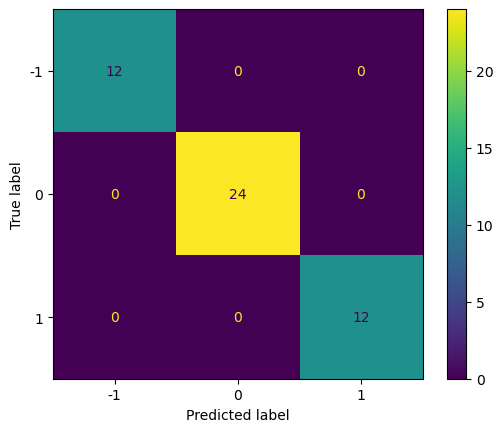

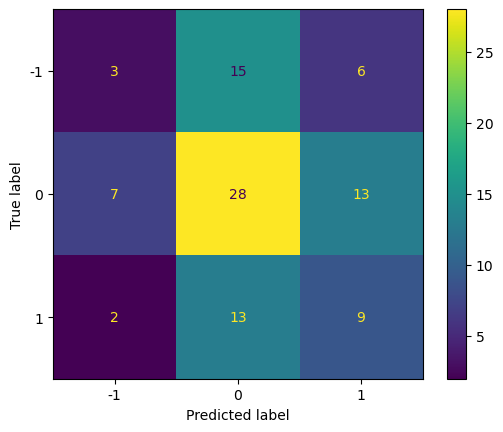

In [13]:
# plot confusion
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

ConfusionMatrixDisplay.from_estimator(
    model,
    X_train,
    y_train,
)
ConfusionMatrixDisplay.from_estimator(
    model,
    X_val,
    y_val,
)

In [14]:
p_gt_phoneme = y_proba_val[np.arange(len(y_proba_val)),
                           metadata.iloc[idxs_val].lexical_evidence]

In [15]:
p_mismatch_to_gt = model.predict_proba(X_val) \
    [np.arange(len(X_val)),
     metadata.iloc[idxs_val].mismatch_left_right + 1]

In [16]:
np.corrcoef(p_gt_phoneme, p_mismatch_to_gt)

array([[1.        , 0.04327375],
       [0.04327375, 1.        ]])

<Axes: >

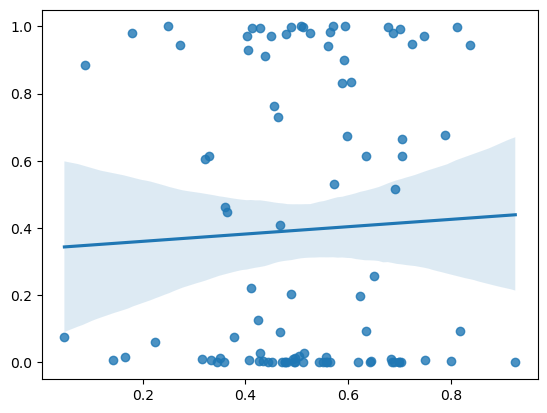

In [17]:
sns.regplot(x=p_gt_phoneme, y=p_mismatch_to_gt)

In [75]:
from src.models.causal3 import run_causal3_analysis
from tqdm.auto import trange

all_results = []
all_results_meta = {}
populations_dict = {}
n_repeats = 20

split_strategy = "extreme"  # "extreme", "stratify"

for repeat in trange(n_repeats):
    for population in tqdm(populations):
        ret = run_causal3_analysis(
            epochs, subject=population["subject"],
            phoneme_pair=population["phoneme_pair"],
            population_A=population["electrodes_a"],
            population_A_window=population["window_a"],
            population_B=population["electrodes_b"],
            population_B_window=population["window_b"],
            split_strategy=split_strategy,
        )

        name = f"{population['subject']}_{population['phoneme_pair']}_A{population['cluster_a']}_B{population['cluster_b']}"
        result = pd.Series({
            "name": name,
            "repeat": repeat,
            "corr": ret.correlation_p,
            "window_a_start": population["window_a"][0],
            "window_a_end": population["window_a"][1],
            "window_b_start": population["window_b"][0],
            "window_b_end": population["window_b"][1],

            "phase1_scores": ret.phase1_test_scores.mean(),
            "phase1_val_score": ret.phase1_val_score,
            "phase2_scores": ret.phase2_test_scores.mean(),
        })

        all_results.append(result)
        
        key = (name, repeat)
        populations_dict[key] = population
        all_results_meta[key] = {
            # "idxs_val": idxs_val,
            # "y_proba_val": y_proba_val,
            "p_gt_phoneme": ret.p_gt_phoneme,
            "p_mismatch_to_gt": ret.p_mismatch_to_gt,
        }

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

...

/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1413: RuntimeWarning: divide by zero encountered in log
  return np.log(self.predict_proba(X))


  0%|          | 0/26 [00:00<?, ?it/s]

/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1413: RuntimeWarning: divide by zero encountered in log
  return np.log(self.predict_proba(X))
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
  

  0%|          | 0/26 [00:00<?, ?it/s]

/home/jgauthier/u/transformers/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1413: RuntimeWarning: divide by zero encountered in log
  return np.log(self.predict_proba(X))


In [76]:
all_results_df = pd.DataFrame(all_results)
all_results_df = all_results_df.set_index(["name", "repeat"])

In [77]:
all_results_df.groupby("name")[["corr", "phase1_scores", "phase2_scores"]].agg(["mean", "std"]).sort_values(("corr", "mean"))

corr           phase1_scores           phase2_scores  \
                    mean       std          mean       std          mean   
name                                                                       
EC270_dn_A5_B2 -0.283270  0.135547      0.485417  0.080660      0.419792   
EC282_dn_A0_B3 -0.179428  0.060506      0.627778  0.074969      0.410417   
EC282_dn_A5_B3 -0.167023  0.075829      0.872569  0.056721      0.412500   
EC282_dn_A5_B2 -0.094959  0.075158      0.882292  0.043264      0.385417   
EC270_pb_A3_B4 -0.074060  0.086945      0.572396  0.084800      0.253125   
EC243_bm_A6_B4 -0.071417  0.051813      0.758030  0.036058      0.345833   
EC270_dn_A0_B3 -0.061980  0.079385      0.456250  0.073107      0.300000   
EC253_dn_A0_B3 -0.050688  0.046229      0.800260  0.040125      0.395833   
EC287_dn_A5_B1 -0.037076  0.047384      0.573438  0.066086      0.391406   
EC250_dn_A5_B2 -0.026581  0.075984      0.878342  0.028496      0.331250   
EC282_dn_A0_B2 -0.025759  0.106687      0.672569  0.070991      0.386458   
EC287_dn_A5_B2 -0.015639  0.092060      0.591504  0.081573      0.385937   
EC270_dn_A5_B1 -0.010089  0.137674      0.515625  0.093445      0.311458   
EC282_dn_A0_B1 -0.003452  0.089584      0.645312  0.074940      0.355208   
EC287_dn_A5_B3  0.015918  0.089683      0.577734  0.065532      0.399219   
EC282_pb_A3_B4  0.033265  0.088550      0.539410  0.093911      0.396875   
EC282_dn_A5_B1  0.054382  0.085205      0.884201  0.051922      0.366667   
EC250_dn_A5_B3  0.055441  0.027791      0.861111  0.043766      0.341667   
EC250_bm_A6_B4  0.059096  0.063549      0.661458  0.059999      0.353125   
EC253_dn_A5_B3  0.070715  0.056285      0.628429  0.057818      0.376563   
EC270_dn_A5_B3  0.094969  0.173046      0.501215  0.098572      0.318750   
EC270_dn_A0_B2  0.100942  0.125007      0.462500  0.069349      0.431250   
EC282_bm_A3_B4  0.112754  0.100886      0.543403  0.082871      0.359375   
EC270_dn_A0_B1  0.117147  0.103017      0.457986  0.090949      0.351042   
EC282_bm_A6_B4  0.142603  0.075026      0.837847  0.033553      0.351042   
EC260_dn_A5_B1  0.276040  0.028529      0.823134  0.028049      0.360938   

                          
                     std  
name                      
EC270_dn_A5_B2  0.067347  
EC282_dn_A0_B3  0.050173  
EC282_dn_A5_B3  0.041994  
EC282_dn_A5_B2  0.057154  
EC270_pb_A3_B4  0.079482  
EC243_bm_A6_B4  0.043753  
EC270_dn_A0_B3  0.044529  
EC253_dn_A0_B3  0.056552  
EC287_dn_A5_B1  0.047684  
EC250_dn_A5_B2  0.045793  
EC282_dn_A0_B2  0.060258  
EC287_dn_A5_B2  0.043343  
EC270_dn_A5_B1  0.063218  
EC282_dn_A0_B1  0.049428  
EC287_dn_A5_B3  0.063007  
EC282_pb_A3_B4  0.057144  
EC282_dn_A5_B1  0.060229  
EC250_dn_A5_B3  0.050649  
EC250_bm_A6_B4  0.021614  
EC253_dn_A5_B3  0.041704  
EC270_dn_A5_B3  0.063082  
EC270_dn_A0_B2  0.057394  
EC282_bm_A3_B4  0.057304  
EC270_dn_A0_B1  0.075654  
EC282_bm_A6_B4  0.061681  
EC260_dn_A5_B1  0.042652

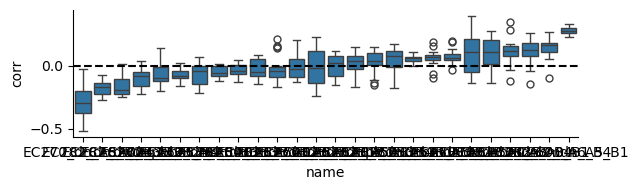

In [92]:
order = all_results_df.groupby("name").agg(["mean", "std"]).sort_values(("corr", "mean")).index
g = sns.catplot(data=all_results_df.reset_index(), x="name", y="corr", order=order, kind="box", aspect=3, height=2)
g.axes.flat[0].axhline(0, color="k", linestyle="--")

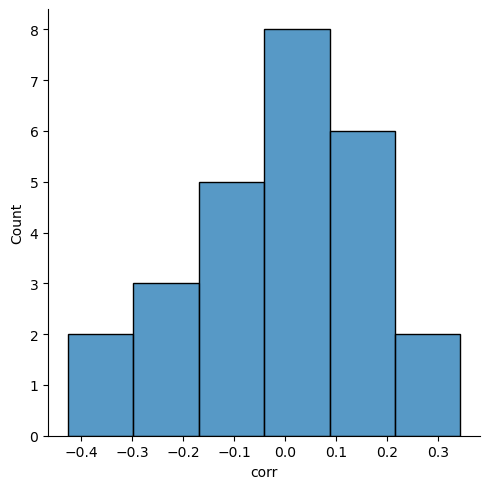

In [21]:
sns.displot(all_results_df["corr"])

<Axes: >

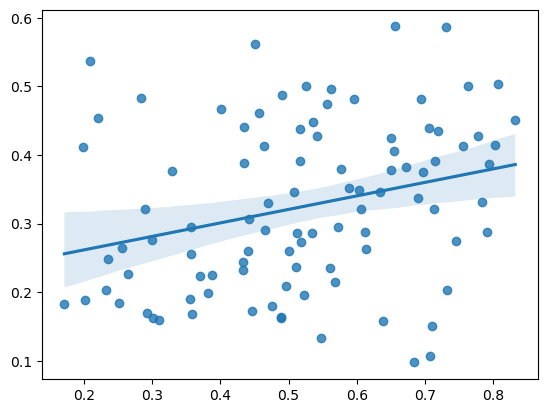

In [96]:
plot_key = "EC260_dn_A5_B1"
# merge estimated probabilities from repeats
p_gt_phoneme = np.array([all_results_meta[(plot_key, repeat)]["p_gt_phoneme"]
                        for repeat in range(n_repeats)]).T
p_mismatch_to_gt = np.array([all_results_meta[(plot_key, repeat)]["p_mismatch_to_gt"]
                              for repeat in range(n_repeats)]).T

sns.regplot(x=p_gt_phoneme.mean(1), y=p_mismatch_to_gt.mean(1))

## Plot HGA

In [189]:
plot_y_proba_val

array([7.63226240e-02, 1.97541021e-01, 3.67360922e-01, 1.32969036e-01,
       5.31520353e-01, 4.57695338e-03, 3.02424339e-02, 8.46169406e-01,
       9.41891972e-01, 1.04352446e-01, 2.39657512e-01, 9.00661908e-01,
       4.92957607e-01, 7.24079653e-01, 3.72257551e-01, 3.39152511e-01,
       9.67429441e-01, 8.47815884e-01, 3.18344689e-01, 4.70195115e-01,
       8.71681898e-01, 7.93370030e-01, 2.43710420e-02, 9.25791648e-01,
       1.52070503e-01, 4.58474256e-01, 9.47094435e-01, 5.80757777e-01,
       1.12744906e-02, 7.49026685e-01, 9.71553439e-01, 3.93484410e-03,
       5.97829918e-04, 9.58664817e-02, 3.46179612e-01, 4.45858158e-02,
       3.69752267e-01, 4.86661902e-01, 1.34082029e-01, 5.35621332e-01,
       6.74608084e-01, 3.68681908e-01, 1.25558124e-04, 4.97292286e-04,
       4.92690779e-01, 3.17171014e-01, 3.51351520e-01, 7.40594507e-01,
       7.03532211e-01, 1.37538433e-01, 2.38234911e-03, 9.37161034e-01,
       1.01038317e-01, 1.29752649e-01, 8.32171575e-01, 8.01000714e-01,
      

In [194]:
def plot_expt_hga(plot_expt):
    # plot_expt = "EC282_dn_A0_B1"
    plot_subject, plot_phoneme_pair, plot_cluster_a, plot_cluster_b = plot_expt.split("_")
    plot_cluster_a = int(plot_cluster_a[1:])
    plot_cluster_b = int(plot_cluster_b[1:])
    plot_population = populations_dict[plot_expt]

    plot_idxs_val = all_results_meta[plot_expt]["idxs_val"]
    plot_y_proba_val = all_results_meta[plot_expt]["y_proba_val"][:, 1]

    plot_n_quantiles = 4
    plot_quantiles, bins = pd.cut(plot_y_proba_val, plot_n_quantiles, labels=False, retbins=True)
    print(bins)

    plot_epochs = epochs[plot_subject][f"phoneme_pair == '{plot_phoneme_pair}'"][plot_idxs_val] \
        .copy().pick(plot_population["electrodes_b"]).crop(*plot_population["window_b"])
    plot_X = plot_epochs.get_data()

    quantile_values = {}
    for i in range(plot_n_quantiles):
        quantile_values[i] = plot_X[plot_quantiles == i]

    n_cols = 2
    n_rows = int(np.ceil(len(plot_population["electrodes_b"]) / n_cols))
    f, axs = plt.subplots(n_rows, n_cols, figsize=(10 * n_cols, 5 * n_rows), sharex=True)

    palette = sns.color_palette("husl", plot_n_quantiles)
    for channel_idx in range(len(plot_population["electrodes_b"])):
        for i in range(plot_n_quantiles):
            ax = axs.flat[channel_idx]
            ax.plot(plot_epochs.times, quantile_values[i][:, channel_idx].mean(0), label=f"Quantile {i} - {plot_population['electrodes_b'][channel_idx]}")
            ax.fill_between(plot_epochs.times,
                            quantile_values[i][:, channel_idx].mean(0) - quantile_values[i][:, channel_idx].std(0) / np.sqrt(len(quantile_values[i])),
                            quantile_values[i][:, channel_idx].mean(0) + quantile_values[i][:, channel_idx].std(0) / np.sqrt(len(quantile_values[i])),
                            alpha=0.2)
            # for j in range(quantile_values[i].shape[0]):
            #     ax.plot(plot_epochs.times, quantile_values[i][j, channel_idx], color=palette[i], alpha=0.2)
            ax.legend()

    # plot rasters sorted by probability
    f, axs = plt.subplots(n_rows, n_cols, figsize=(10 * n_cols, 5 * n_rows), sharex=True)
    for channel_idx in range(len(plot_population["electrodes_b"])):
        # resort
        sorted_idxs = np.argsort(plot_y_proba_val)
        sorted_X = plot_X[sorted_idxs]

        sns.heatmap(sorted_X[:, channel_idx], ax=axs.flat[channel_idx], cmap="RdBu", cbar=False)

[-8.55110309e-04  2.45292666e-01  4.90459775e-01  7.35626883e-01
  9.80793992e-01]


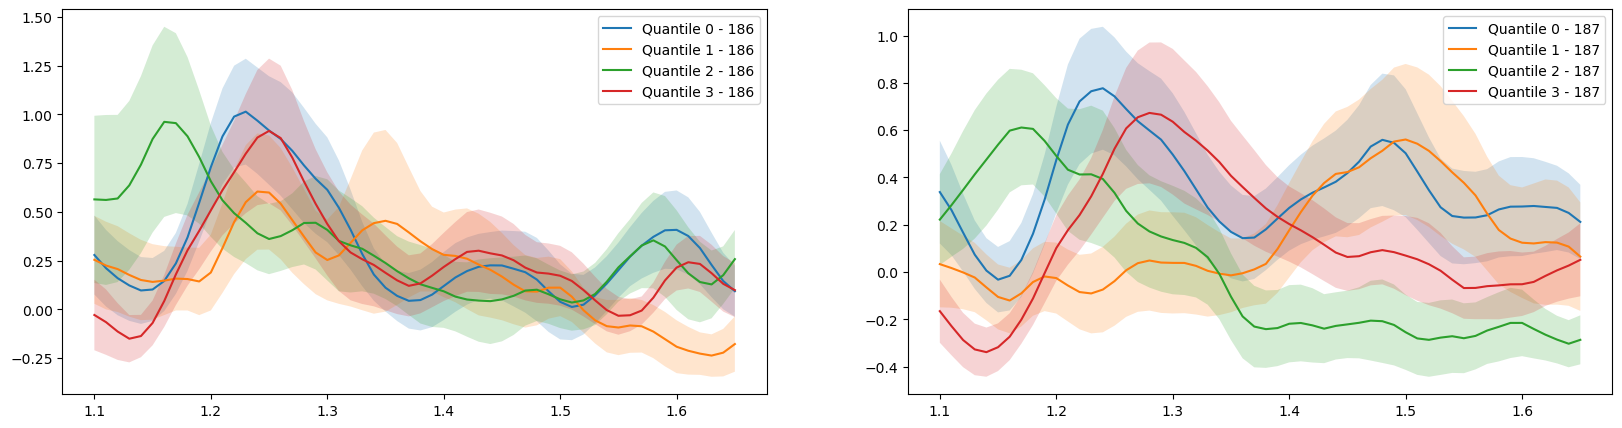

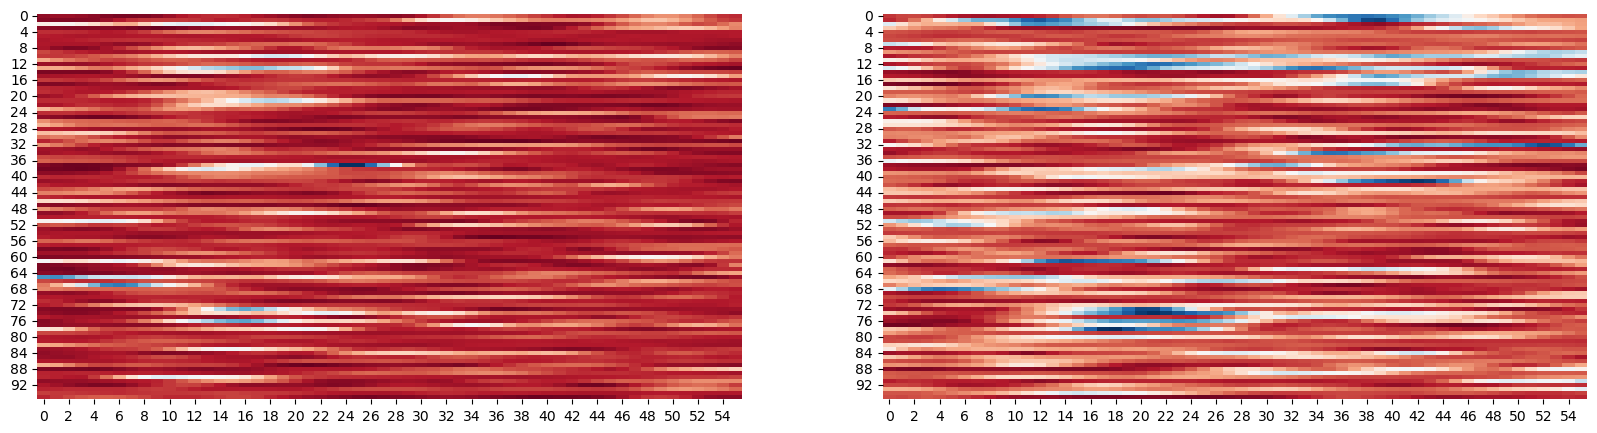

In [195]:
plot_expt_hga("EC282_dn_A0_B1")

[0.08775186 0.26215869 0.43587068 0.60958267 0.78329465]


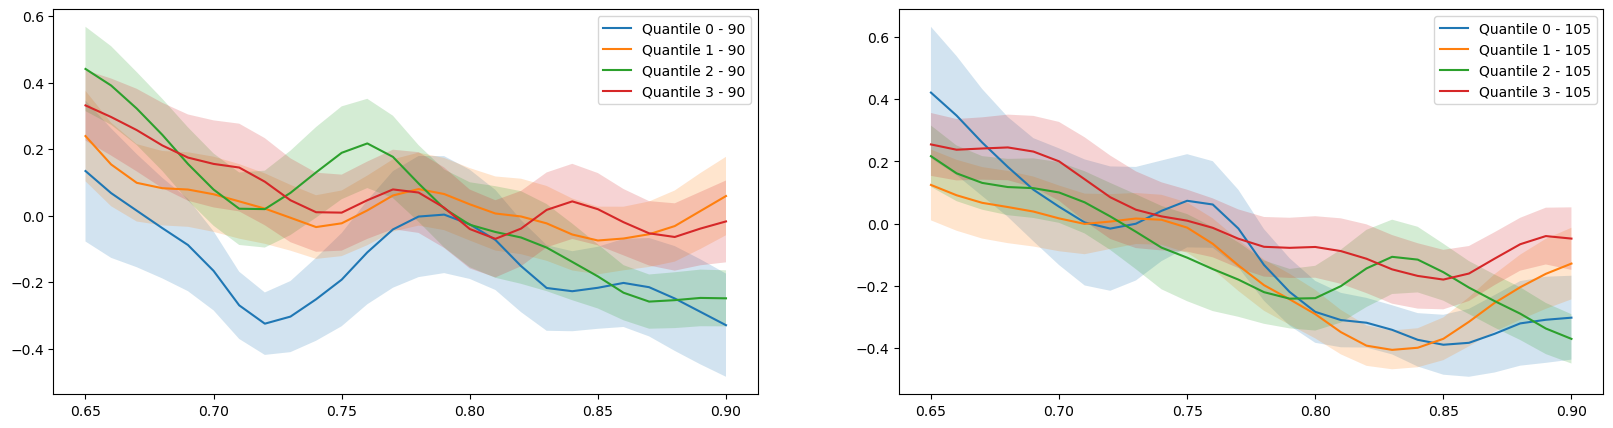

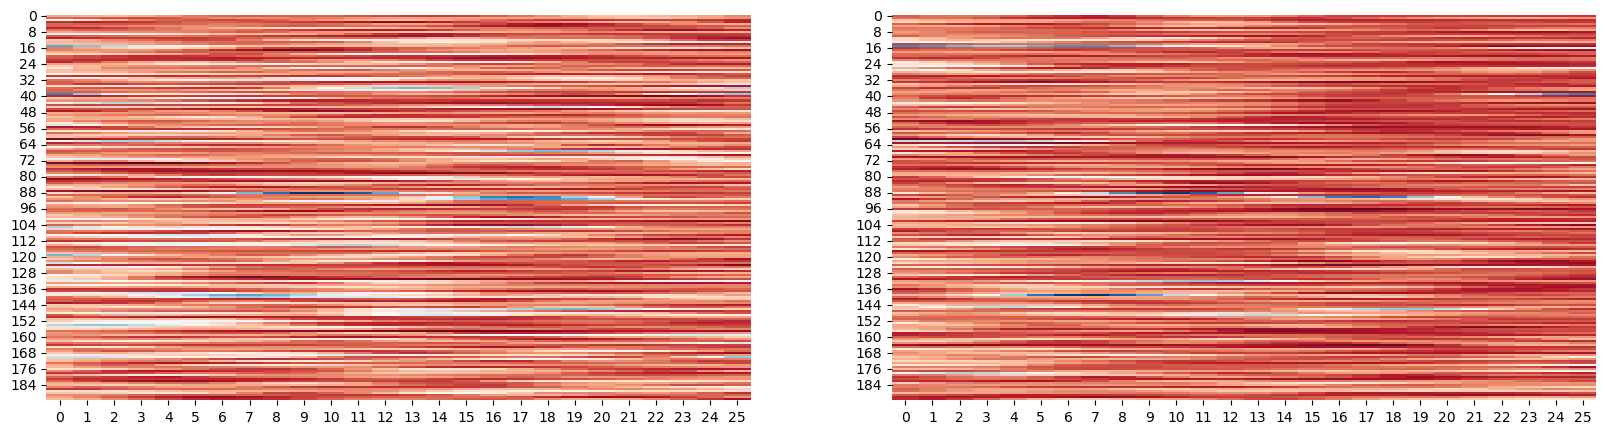

In [196]:
plot_expt_hga("EC243_bm_A6_B4")

[0.00197395 0.2521734  0.50137604 0.75057868 0.99978132]


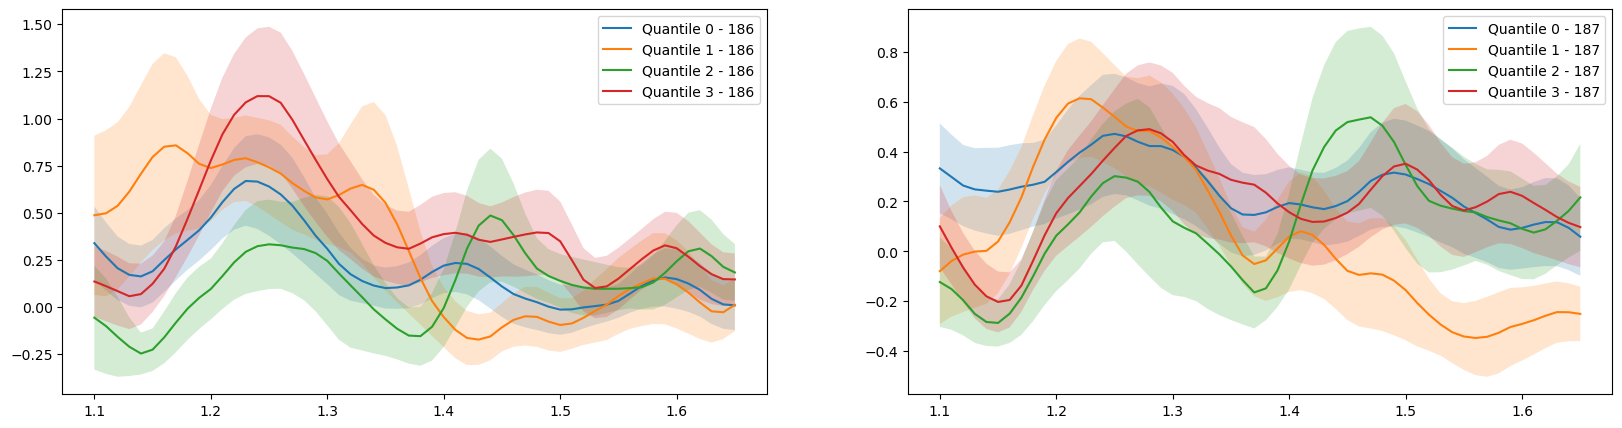

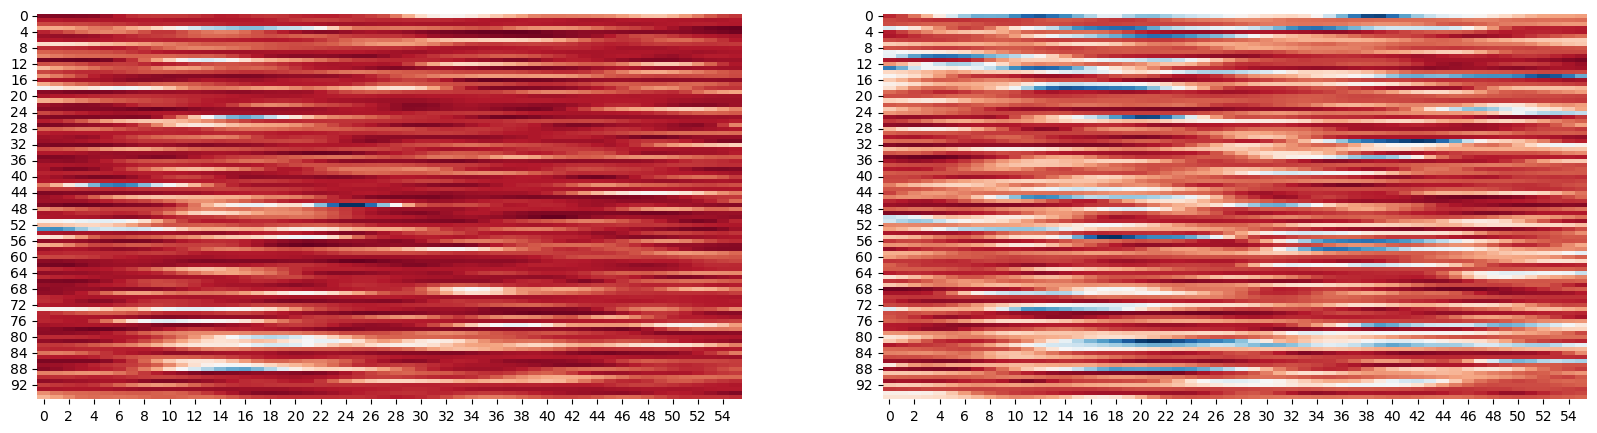

In [197]:
plot_expt_hga("EC282_dn_A5_B1")

---

[0.16113102 0.31416581 0.46659091 0.619016   0.77144109]


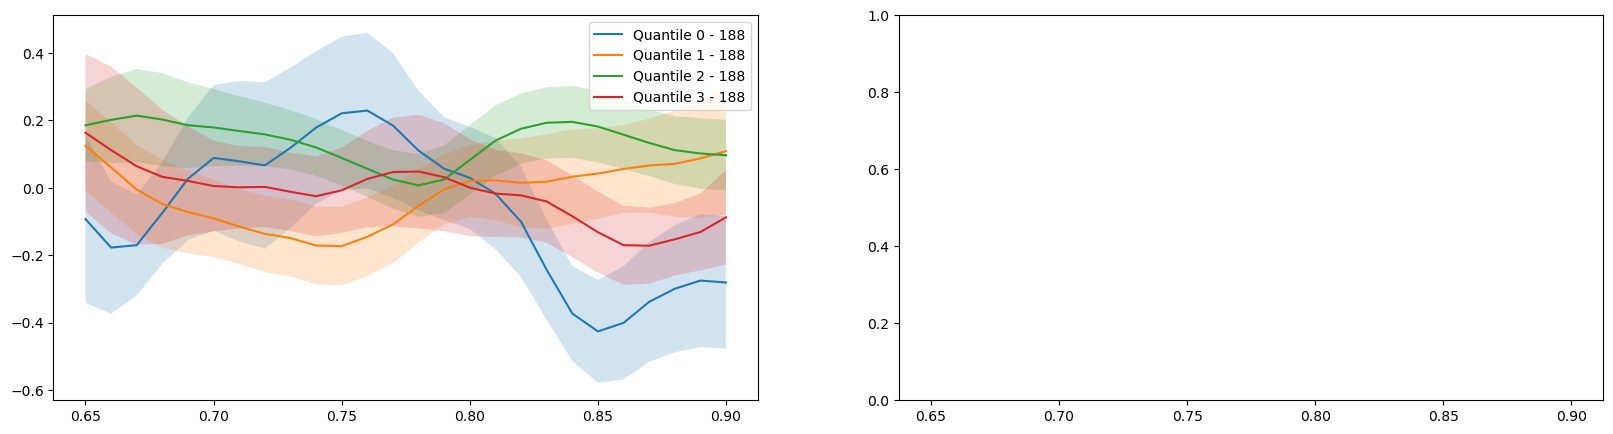

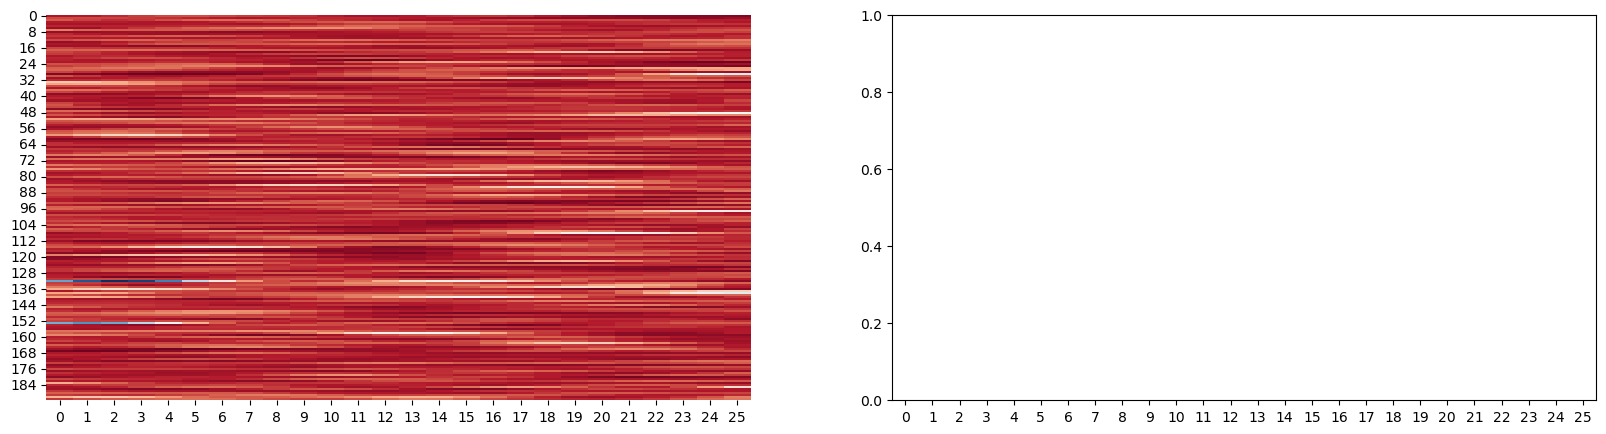

In [198]:
plot_expt_hga("EC250_bm_A6_B4")

[0.19844115 0.37251088 0.5458871  0.71926333 0.89263956]


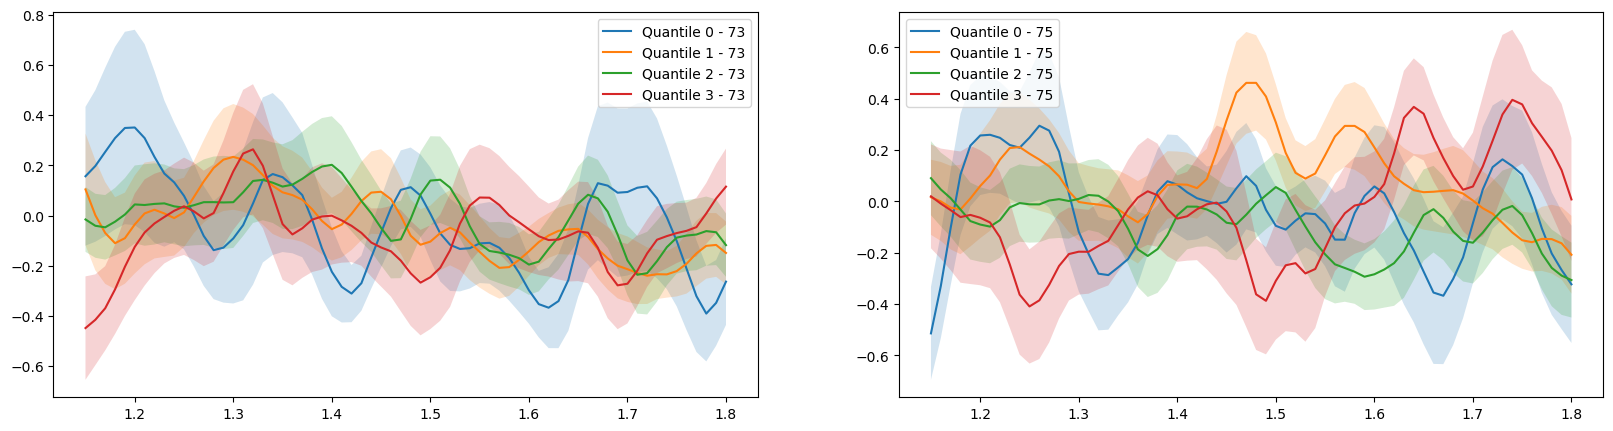

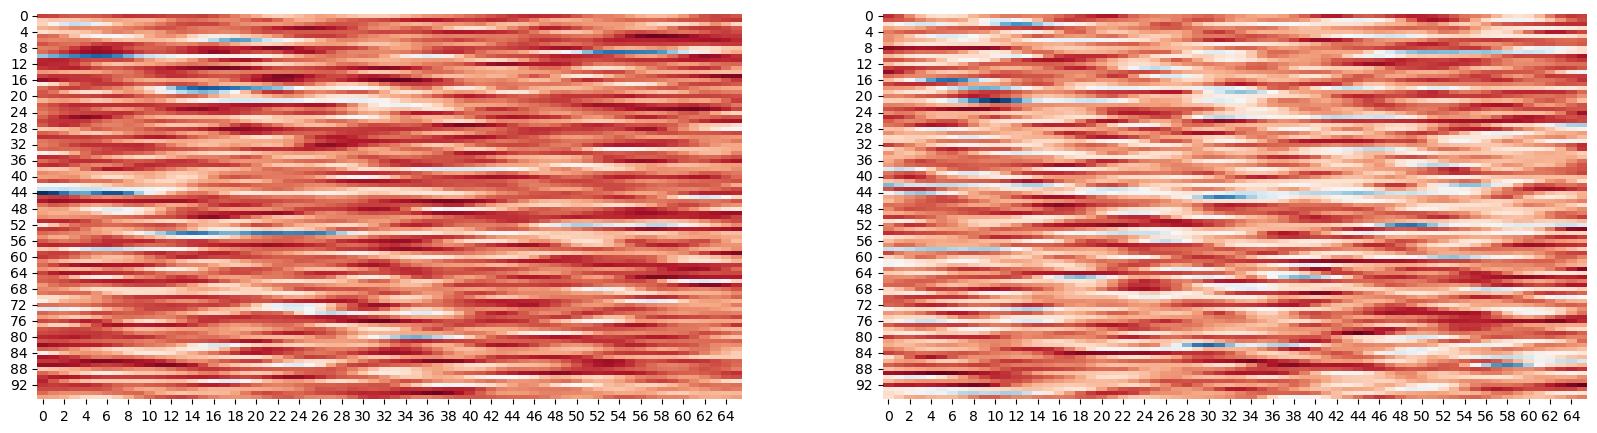

In [199]:
plot_expt_hga("EC270_dn_A0_B3")